__Markus Mulvihill__

__Last updated April 2026__

# Necessary Packages and Modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tomllib

# Introduction

Within this file, different methods of parameter estimation will be implemented and compared to predict the Insulin Sensitivity $\, SI$ in patients

In [2]:
try:
    SI_ests = np.load("../scripts/variables/SI_ests_augment_static_04.npy")
    SI_errs = np.load("../scripts/variables/SI_errs_augment_static_04.npy")
    SI_true_arr = np.load("../scripts/variables/SI_true_arr_augment_static_04.npy")
    print("Loaded variables")
except Exception:
    print("Run 04_Paramater_estimation_augment.py")

Loaded variables


In [3]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)
curr_module = "04"
num_particles = cfg[curr_module]["num_particles"]
low_perc = cfg[curr_module]["low_perc"]
high_perc = cfg[curr_module]["high_perc"]
CI = cfg[curr_module]["CI"]

filters = ["EKF"]
pfs = [f"PF {particles}" for particles in num_particles]
filters.extend(pfs)

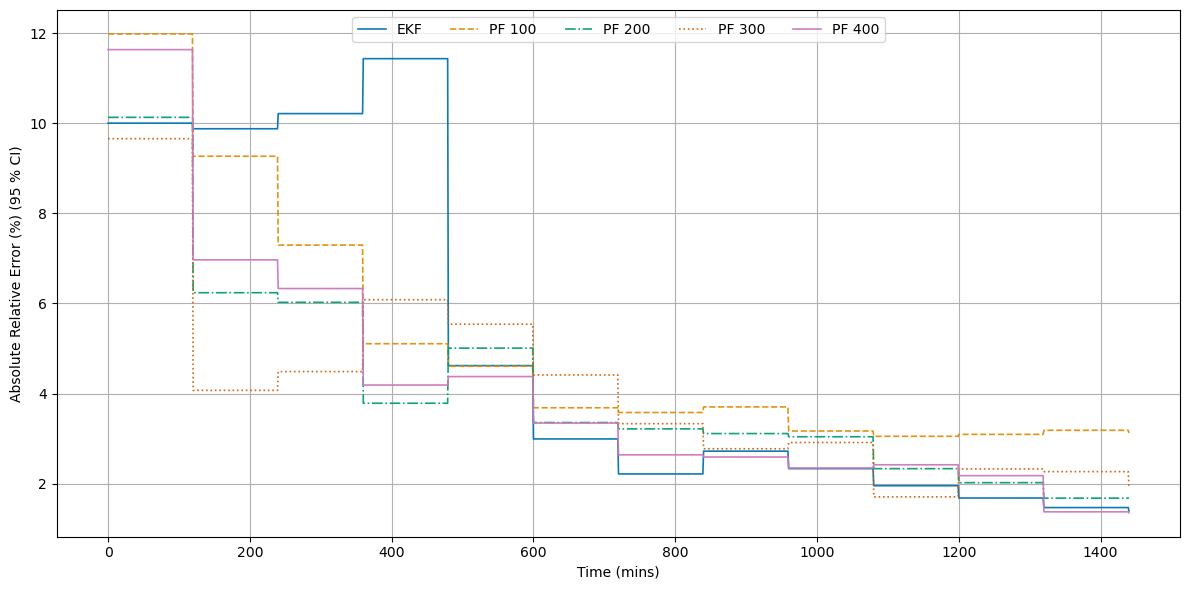

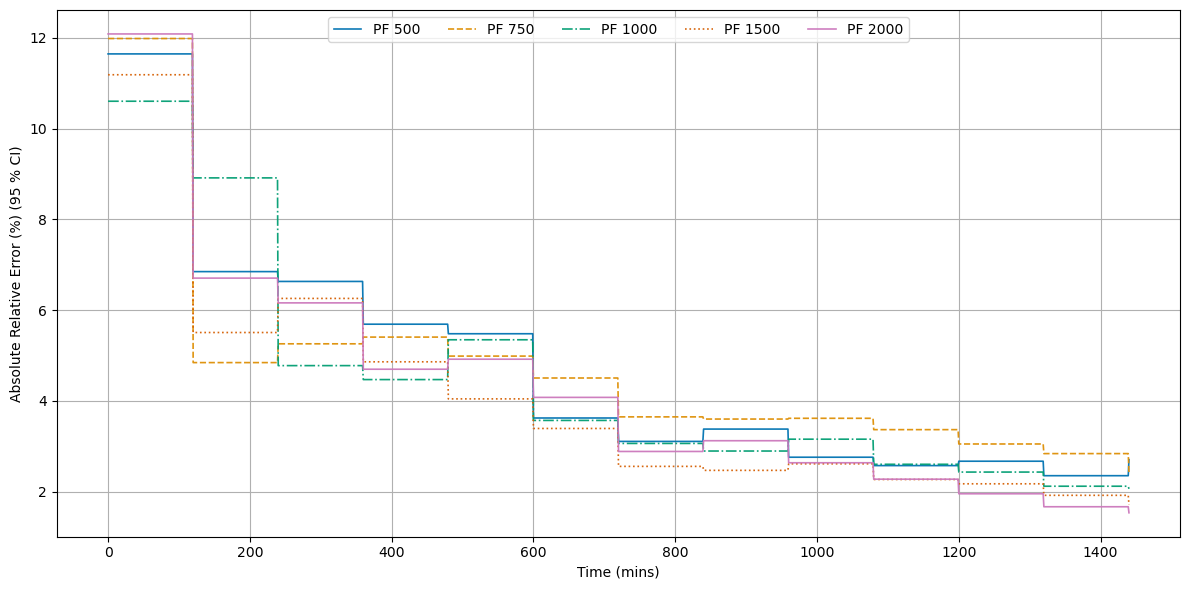

In [5]:
mean_err = np.mean(SI_errs, axis=1)
ci_low = np.percentile(SI_errs, low_perc, axis=1)
ci_high = np.percentile(SI_errs, high_perc, axis=1)
time = np.arange(mean_err.shape[1])
num_plots = 5
num_filters = len(filters)
palette = sns.color_palette("colorblind", num_filters)

fig, ax = plt.subplots(figsize=(12, 6))

for i in range(num_plots):
    ax.plot(
        time,
        mean_err[i],
        color=palette[i],
        linewidth=1.2,
        alpha=0.95,
        linestyle=["-", "--", "-.", ":"][i % 4],
        label=f"{filters[i]}",
    )
    #ax.fill_between(time, ci_low[i], ci_high[i], color=palette[i], alpha=0.18)
ax.set_ylabel(f"Absolute Relative Error (%) ({CI} % CI)")
ax.legend(loc="upper center", ncols=num_plots)
ax.set_xlabel("Time (mins)")
ax.grid()
fig.tight_layout()

fig, ax = plt.subplots(figsize=(12,6))

for i in range(num_plots):
    ax.plot(
        time,
        mean_err[i+num_plots],
        color=palette[i],
        linewidth=1.2,
        alpha=0.95,
        linestyle=["-", "--", "-.", ":"][i % 4],
        label=f"{filters[i+num_plots]}",
    )
    #ax.fill_between(time, ci_low[i], ci_high[i], color=palette[i], alpha=0.18)
ax.set_ylabel(f"Absolute Relative Error (%) ({CI} % CI)")
ax.legend(loc="upper center", ncols=num_plots)
ax.set_xlabel("Time (mins)")
ax.grid()
fig.tight_layout()
